# Reachy Mini Python SDK

## 参考

- [Reachy Mini Python SDK Reference](https://huggingface.co/docs/reachy_mini/SDK/python-sdk)
- [API reference](https://huggingface.co/docs/reachy_mini/API/reachymini)
- [App Examples](https://huggingface.co/docs/reachy_mini/examples/minimal_demo)
- [First Connection & Movement](https://github.com/pollen-robotics/reachy_mini/blob/main/docs/notebooks/0-First-Connection-and-Movement.ipynb)
- [Basic Media: Camera & Audio](https://github.com/pollen-robotics/reachy_mini/blob/main/docs/notebooks/1-Basic-Media-Camera-and-Audio.ipynb)

## 概要

- Reachy Miniは、人間とロボットのインタラクションを促すために設計された表現豊かなオープンソースのロボット
- [POLLEN ROBOTICS](https://www.pollen-robotics.com/)が開発（2025年にHuggingFaceが買収）
- [Discordコミュニティ](https://discord.gg/2bAhWfXme9)

## 特徴

- 手頃な価格とコンパクトさ
    - Reachy Mini (Wireless) $449 - $499
    - Reachy Mini Lite $229 - $399
    - Wireless版は自律型ロボットのパッケージで、Raspberry Pi CM4・バッテリー・WiFiアダプタが付属
- 高度なインタラクション
    - カメラ、マイク、スピーカーを備え、頭部・体部・アンテナをモータの動きをモータで制御可能
- AIとの統合
    - Hugging Face上の最新のオープンソースAIモデルを統合し、開発可能
- オープンソース
    - ハードウェア、ソフトウェア、シミュレーション環境が公開されている
    - ハードウェアは営利目的での使用が禁止（Creative Commons BY-SA-NC）

## 開発環境

[Reachy Mini Python SDK](https://github.com/pollen-robotics/reachy_mini)を使用して開発

開発の始め方は、使用するロボットで異なる

1. [Reachy Mini (Wireless)](https://huggingface.co/docs/reachy_mini/platforms/reachy_mini/get_started)
1. [Reachy Mini Lite](https://huggingface.co/docs/reachy_mini/platforms/reachy_mini_lite/get_started)
1. [シミュレーション上のロボット](https://huggingface.co/docs/reachy_mini/platforms/simulation/get_started)

本ノートブックでは、シミュレーション上のロボットを想定して開発

ローカル環境でモデルの推論を行う場合は、Reachy Mini LiteとJetson Orin Nanoを組み合わせる

## シミュレーション環境の構築

シミュレーションは、物理シミュレータエンジンMuJoCoを使用する

MuJoCoのレンダリングは OpenGLを使用するため、依存関係のインストールと処理の重さに注意が必要

### Reachy Mini Python SDKのインストール

情報が古い可能性があるため、[公式ドキュメント](https://huggingface.co/docs/reachy_mini/SDK/installation)を確認すること

SDKは、Python 3.10から3.12に対応

### GitとGit LFSのインストール

```sh
# Linux
sudo apt install git git-lfs
git lfs install

# macOS
# Homebrewをインストール
/bin/bash -c "$(curl -fsSL https://raw.githubusercontent.com/Homebrew/install/HEAD/install.sh)"
echo 'eval "$(/opt/homebrew/bin/brew shellenv)"' >> ~/.zprofile
eval "$(/opt/homebrew/bin/brew shellenv)"
brew --version
brew install git git-lfs
git lfs install

# Windows
# Git for Windowsをインストール https://git-scm.com/install/windows
git lfs install
```

### UVのインストール

```sh
# Linux/macOS
curl -LsSf https://astral.sh/uv/install.sh | sh

# Windows
powershell -ExecutionPolicy ByPass -c "irm https://astral.sh/uv/install.ps1 | iex"

# インストール後ターミナルを開き直し、検証
uv --version
# v0.11.18 古い場合は uv self update を実行
# もしくは curl -LsSf https://astral.sh/uv/install.sh | sh を再実行

# プロジェクトディレクトリ内で、Python 3.12に固定
uv python pin 3.12
```

### 仮想環境を構築

```sh
# 仮想環境を作成
uv venv reachy_mini_env --python 3.12

# Linux/macOS
source reachy_mini_env/bin/activate

# Windows
# Win + R を押し、powershellと入力。Windows Powershellを右クリックし、管理者として実行
powershell Set-ExecutionPolicy RemoteSigned
# Powershellを閉じ、通常のターミナルを開く
reachy_mini_env\Scripts\activate
```

### 仮想環境にSDKをソースからインストール

In [ ]:
import os

if not os.path.exists("reachy_mini"):
    !git clone https://github.com/pollen-robotics/reachy_mini

%cd reachy_mini
!git describe --tags # v1.8.0-12-g4310a71a

In [ ]:
# Linux/Windows
!uv sync --extra mujoco

# macOS
!uv pip install -e "reachy_mini[mujoco]"
# ディレクトリ内にいる場合 uv pip install -e ".[mujoco]"

!uv pip show reachy-mini

インストール時の問題は[Troubleshooting & FAQ](https://huggingface.co/docs/reachy_mini/troubleshooting)を参照

### GStreamerのインストール

Linuxの場合、GStreamerのビルド・インストールが必要

[GStreamer Installation](https://huggingface.co/docs/reachy_mini/SDK/gstreamer-installation)

[GStreamer](https://gstreamer.freedesktop.org/)は、カメラ映像とマイク音声のストリームを受信するためのマルチメディアフレームワーク

Reachy Miniでは、v1.24.x以上であり、WebRTCプラグインが有効化されている必要がある

ビルドとインストールは環境依存のため割愛（複雑）

## クイックスタート

[Quickstart Guide](https://huggingface.co/docs/reachy_mini/SDK/quickstart)


### シミュレーションの起動

```sh
# Windows/Linux
reachy-mini-daemon --sim

# macOS
mjpython -m reachy_mini.daemon.app.main --sim
# otoolの実行エラーが発生する場合 sudo xcodebuild -license accept
# libpython3.12.dylibが見つからない場合 export DYLD_LIBRARY_PATH="/Users/engineercafejp/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib:$DYLD_LIBRARY_PATH"
```

正常だとシミュレーション画面が表示される

![](asset/mujoco.png)

### シミュレーションの引数

reachy_mini/src/reachy_mini/daemon/app/main.py に記載

- --sim	MuJoCoを使ったシミュレーションモードで起動
- --mockup-sim	MuJoCo不要のモックアップシミュレーション（描画なし）
- --scene <name> 読み込むシーン名。emptyかminimal
- --headless GUIなしで起動（ビューワを開かない）
- --no-media カメラ・音声・WebRTC を無効化
- --no-wake-up-on-start	起動時に自動で起き上がらせない
- --no-goto-sleep-on-stop 停止時にスリープ姿勢にしない
- --no-autostart 起動時にデーモンを自動スタートしない
- --kinematics-engine	AnalyticalKinematics(Placo/NN/AnalyticalKinematics)
- --check-collision	衝突判定を有効化
- --fastapi-port <n> APIサーバのポート
- --log-level DEBUG/INFO/WARNING/ERROR/CRITICAL


### Reachy Mini Dashboard

シミュレータを起動した状態で http://localhost:8000 でダッシュボードを表示できる

ダッシュボードから、サンプルのダンス・エモーションやアプリを実行可能

廃止予定なので、[Reachy Mini Control](https://pollen-robotics-reachy-mini.hf.space/download)を推奨


### シミュレーション環境のロボットを動かす

In [1]:
# 複数の動きをまとめて指定

from reachy_mini import ReachyMini
from reachy_mini.utils import create_head_pose
import numpy as np

with ReachyMini() as mini:
    mini.goto_target(
        head=create_head_pose(z=10, mm=True),  # Up 10mm
        antennas=np.deg2rad([45, 45]),  # Antennas out
        body_yaw=np.deg2rad(30),  # Turn body
        duration=2.0,  # Take 2 seconds
        method="minjerk",  # Smooth acceleration
    )

Cannot change resolution of Mujoco simulated camera for now.
No Reachy Mini Audio USB device found!
No Reachy Mini Audio Source card found.
No specific audio card found, using default audio source.
No Reachy Mini Audio Sink card found.
No specific audio card found, using default audio sink.


In [2]:
# 逐次的に動きを指定

from reachy_mini import ReachyMini
from reachy_mini.utils import create_head_pose

# Connects to the simulation running on localhost
with ReachyMini() as mini:
    print("Connected to simulation!")

    # Look up and tilt head
    print("Moving head...")
    mini.goto_target(
        head=create_head_pose(z=20, roll=10, mm=True, degrees=True), duration=1.0
    )

    # Wiggle antennas
    print("Wiggling antennas...")
    mini.goto_target(antennas=[0.6, -0.6], duration=0.3)
    mini.goto_target(antennas=[-0.6, 0.6], duration=0.3)

    # Reset to rest position
    mini.goto_target(head=create_head_pose(), antennas=[0, 0], duration=1.0)

Cannot change resolution of Mujoco simulated camera for now.
No Reachy Mini Audio USB device found!
No Reachy Mini Audio Source card found.
No specific audio card found, using default audio source.
No Reachy Mini Audio Sink card found.
No specific audio card found, using default audio sink.


Connected to simulation!
Moving head...
Wiggling antennas...


### 録画済みのダンス・エモーションの実行

サンプルのダンス・エモーションは、Pythonスクリプト経由でも実行が可能

- [Reachy Mini Dances Library （19種類）](https://huggingface.co/datasets/pollen-robotics/reachy-mini-dances-library)
- [Reachy Mini Emotions Library（81種類）](https://huggingface.co/datasets/pollen-robotics/reachy-mini-emotions-library)

In [3]:
from reachy_mini.motion.recorded_move import RecordedMoves

dances = RecordedMoves("pollen-robotics/reachy-mini-dances-library")
print("Dances:", ", ".join([move for move in dances.list_moves()]))

emotions = RecordedMoves("pollen-robotics/reachy-mini-emotions-library")
print("Emotions:", ", ".join([move for move in emotions.list_moves()]))

/Users/engineercafejp/reachy-mini-workshop/reachy_mini_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dances: stumble_and_recover, chin_lead, head_tilt_roll, jackson_square, pendulum_swing, side_glance_flick, grid_snap, simple_nod, side_to_side_sway, polyrhythm_combo, interwoven_spirals, uh_huh_tilt, chicken_peck, yeah_nod, side_peekaboo, dizzy_spin, neck_recoil, groovy_sway_and_roll, sharp_side_tilt
Emotions: fear1, exhausted1, loving1, dance3, boredom2, relief1, anxiety1, disgusted1, welcoming1, impatient1, sad1, helpful2, resigned1, amazed1, thoughtful2, lost1, surprised1, serenity1, displeased1, incomprehensible2, irritated2, yes_sad1, dance2, understanding1, contempt1, inquiring1, rage1, attentive2, no1, oops1, proud3, reprimand3, reprimand2, scared1, no_excited1, come1, proud2, success1, enthusiastic2, laughing1, dying1, success2, enthusiastic1, curious1, laughing2, tired1, reprimand1, proud1, grateful1, frustrated1, calming1, attentive1, furious1, oops2, irritated1, yes1, confused1, understanding2, dance1, shy1, inquiring2, uncertain1, thoughtful1, surprised2, displeased2, impat

In [4]:
# move = emotions.get("amazed1")
move = dances.get("neck_recoil")

with ReachyMini() as mini:
    await mini.async_play_move(move, initial_goto_duration=1.0)

Cannot change resolution of Mujoco simulated camera for now.
No Reachy Mini Audio USB device found!
No Reachy Mini Audio Source card found.
No specific audio card found, using default audio source.
No Reachy Mini Audio Sink card found.
No specific audio card found, using default audio sink.


### デバイスの確認

In [12]:
# 利用可能なオーディオ・カメラデバイスの一覧

import gi
gi.require_version("Gst", "1.0")
from gi.repository import Gst

from reachy_mini.media.device_detection import gst_monitor_devices

Gst.init(None)

print("=== Audio Input (Microphone) ===")
for d in gst_monitor_devices("Audio/Source"):
    print(f"  [{d.index}] {d.display_name}")
    print(f"       class={d.device_class}  props={dict(list(d.properties.items())[:4])}")

print()
print("=== Audio Output (Speaker) ===")
for d in gst_monitor_devices("Audio/Sink"):
    print(f"  [{d.index}] {d.display_name}")
    print(f"       class={d.device_class}  props={dict(list(d.properties.items())[:4])}")

print()
print("=== Camera ===")
for d in gst_monitor_devices("Video/Source"):
    print(f"  [{d.index}] {d.display_name}")
    print(f"       class={d.device_class}  props={dict(list(d.properties.items())[:4])}")



=== Audio Input (Microphone) ===
  [0] ZoomAudioDevice
       class=Audio/Source  props={'is-default': 'False', 'transport': 'virt', 'unique-id': 'zoom.us.zoomaudiodevice.001'}
  [1] MacBook Airのマイク
       class=Audio/Source  props={'is-default': 'True', 'transport': 'bltn', 'unique-id': 'BuiltInMicrophoneDevice'}
  [2] iPhone12 aip Microphone
       class=Audio/Source  props={'is-default': 'False', 'transport': 'ccwd', 'unique-id': 'B0606BEF-9283-41F3-A575-B16200000003'}

=== Audio Output (Speaker) ===
  [0] ZoomAudioDevice
       class=Audio/Sink  props={'is-default': 'False', 'transport': 'virt', 'unique-id': 'zoom.us.zoomaudiodevice.001'}
  [1] MacBook Airのスピーカー
       class=Audio/Sink  props={'is-default': 'True', 'transport': 'bltn', 'unique-id': 'BuiltInSpeakerDevice'}

=== Camera ===
  [0] MacBook Airカメラ
       class=Video/Source  props={'device.api': 'avf', 'avf.unique_id': '6C707041-05AC-0010-000C-000000000001', 'avf.model_id': 'MacBook Airカメラ', 'avf.has_flash': 'False'}
  [1

In [13]:
# Reachy Mini が現在使用しているデバイスを確認

from reachy_mini.media.device_detection import get_audio_device, get_video_device

mic_id   = get_audio_device("Source")
spk_id   = get_audio_device("Sink")
cam_path, cam_specs = get_video_device()

print("=== Reachy Mini が選択したデバイス ===")
print(f"  Microphone : {mic_id or '(not found / sim モードでは未使用)'}")
print(f"  Speaker    : {spk_id or '(not found / sim モードでは未使用)'}")
print(f"  Camera     : {cam_path or '(not found — sim モードは MuJoCo UDP 経由)'}")
if cam_specs:
    print(f"  Camera Specs: {cam_specs}")


No Reachy Mini Audio Source card found.
No Reachy Mini Audio Sink card found.
No camera found.


=== Reachy Mini が選択したデバイス ===
  Microphone : (not found / sim モードでは未使用)
  Speaker    : (not found / sim モードでは未使用)
  Camera     : (not found — sim モードは MuJoCo UDP 経由)


In [ ]:
# カメラの解像度とフレームレートの一覧

from reachy_mini.media.camera_constants import (
    MujocoCameraSpecs,
    ReachyMiniLiteCamSpecs,
    ReachyMiniWirelessCamSpecs,
    ArducamSpecs,
)

for specs_cls in [MujocoCameraSpecs, ReachyMiniLiteCamSpecs, ReachyMiniWirelessCamSpecs, ArducamSpecs]:
    specs = specs_cls()
    print(f"\n【{specs.name}】 デフォルト: {specs.default_resolution.name}")
    for r in specs.available_resolutions:
        w, h, fps, _ = r.value
        marker = " ← default" if r == specs.default_resolution else ""
        print(f"  {w:4d}x{h:<4d} @{fps:2d}fps  ({r.name}){marker}")



【mujoco】 デフォルト: R1280x720at60fps
  1280x720  @60fps  (R1280x720at60fps) ← default

【lite】 デフォルト: R1920x1080at60fps
  1920x1080 @60fps  (R1920x1080at60fps) ← default
  3840x2592 @30fps  (R3840x2592at30fps)
  3840x2160 @30fps  (R3840x2160at30fps)
  3264x2448 @30fps  (R3264x2448at30fps)

【wireless】 デフォルト: R1280x720at30fps
  1280x720  @30fps  (R1280x720at30fps) ← default
  1920x1080 @30fps  (R1920x1080at30fps)
  1280x720  @60fps  (R1280x720at60fps)
  3840x2592 @10fps  (R3840x2592at10fps)
  3840x2160 @10fps  (R3840x2160at10fps)
  3264x2448 @10fps  (R3264x2448at10fps)
  3072x1728 @10fps  (R3072x1728at10fps)

【arducam】 デフォルト: R1280x720at30fps
  2304x1296 @30fps  (R2304x1296at30fps)
  4608x2592 @10fps  (R4608x2592at10fps)
  1920x1080 @30fps  (R1920x1080at30fps)
  1600x1200 @30fps  (R1600x1200at30fps)
  1280x720  @30fps  (R1280x720at30fps) ← default


In [14]:
# 現在のオーディオ音量を確認

from reachy_mini.daemon.app.routers.volume_control import get_volume_control

vc = get_volume_control()

output_vol = vc.get_output_volume()
input_vol  = vc.get_input_volume()

print(f"プラットフォーム : {vc.platform_name}")
print(f"スピーカー  ({vc.output_device.name}): {output_vol}%")
print(f"マイク      ({vc.input_device.name}) : {input_vol}%")


プラットフォーム : Darwin
スピーカー  (MacBook Airのス): 100%
マイク      (MacBook Airの) : 51%


In [15]:
# スピーカーとマイクの音量を100%に設定

from reachy_mini.daemon.app.routers.volume_control import get_volume_control

vc = get_volume_control()

ok_out = vc.set_output_volume(100)
ok_in  = vc.set_input_volume(100)

print(f"スピーカー  : {'✓ 100%' if ok_out else '✗ 設定失敗'}")
print(f"マイク      : {'✓ 100%' if ok_in  else '✗ 設定失敗'}")

# 確認
print(f"\n設定後 — スピーカー: {vc.get_output_volume()}%  マイク: {vc.get_input_volume()}%")


スピーカー  : ✓ 100%
マイク      : ✓ 100%

設定後 — スピーカー: 100%  マイク: 100%


### カメラでの撮影

In [5]:
%pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 3.0 MB/s  0:00:022.9 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 2.5 MB/s  0:00:012.5 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 3.6 MB/s  0:00:01m 3.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ourpy]
Note: you may need to restart the kernel to use updated packages.


Cannot change resolution of Mujoco simulated camera for now.
No Reachy Mini Audio USB device found!
No Reachy Mini Audio Source card found.
No specific audio card found, using default audio source.
No Reachy Mini Audio Sink card found.
No specific audio card found, using default audio sink.


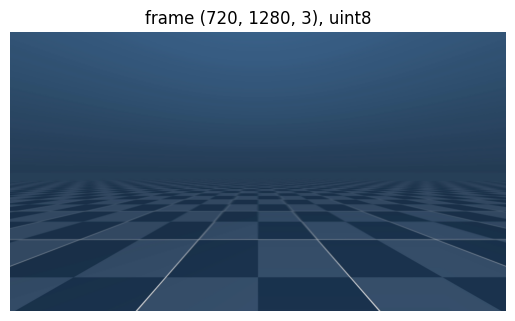

In [6]:
from reachy_mini import ReachyMini
import matplotlib.pyplot as plt

with ReachyMini(media_backend="default") as mini:
    frame = mini.media.get_frame()
    plt.imshow(frame[:, :, ::-1])  # BGR -> RGB に変換して表示
    plt.axis("off")
    plt.title(f"frame {frame.shape}, {frame.dtype}")
    plt.show()

### オーディオ

In [8]:
# 録音

from reachy_mini import ReachyMini
from scipy.signal import resample
import time
from IPython.display import Audio

with ReachyMini(media_backend="default") as mini:
    mini.media.start_recording()
    record_seconds = 3
    in_sr  = mini.media.get_input_audio_samplerate()
    out_sr = mini.media.get_output_audio_samplerate()
    target_samples = int(record_seconds * in_sr)
    audio_samples = []
    collected = 0
    print(f"Recording audio for {record_seconds} seconds at {in_sr} Hz...")

    while collected < target_samples:
        samples = mini.media.get_audio_sample()
        if samples is not None:
            audio_samples.append(samples)
            collected += len(samples)
            print(f"\r  {collected/in_sr:.1f}s", end="")
        else:
            time.sleep(0.01)
    print()
    print(f"{len(audio_samples)} audio samples collected.")
    mini.media.stop_recording()

audio_data = np.concatenate(audio_samples, axis=0)[:target_samples]
print(f"Recorded audio: {len(audio_data)} samples at {in_sr} Hz")
mono = audio_data.mean(axis=1)
display(Audio(data=mono, rate=out_sr))

Cannot change resolution of Mujoco simulated camera for now.
No Reachy Mini Audio USB device found!
No Reachy Mini Audio Source card found.
No specific audio card found, using default audio source.
No Reachy Mini Audio Sink card found.
No specific audio card found, using default audio sink.


Recording audio for 3 seconds at 16000 Hz...
  3.0s
301 audio samples collected.
Recorded audio: 48000 samples at 16000 Hz


In [18]:
# 再生

from reachy_mini import ReachyMini
from scipy.signal import resample
import time

with ReachyMini(media_backend="default") as mini:
    mini.media.start_playing()

    print(f"Original audio: {len(audio_data)} samples at {in_sr} Hz")

    out_sr = mini.media.get_output_audio_samplerate()
    num = int(round(len(audio_data) * out_sr / in_sr))
    print(f"Resampling audio to {num} samples at {out_sr} Hz...")
    samples = resample(audio_data, num)

    mini.media.push_audio_sample(samples)
    wait_seconds = len(samples) / mini.media.get_output_audio_samplerate()
    print(f"Playing audio for {wait_seconds:.2f} seconds at {out_sr} Hz...")
    time.sleep(wait_seconds)
    print("Done playing.")

    mini.media.stop_recording()

Cannot change resolution of Mujoco simulated camera for now.
No Reachy Mini Audio USB device found!
No Reachy Mini Audio Source card found.
No specific audio card found, using default audio source.
No Reachy Mini Audio Sink card found.
No specific audio card found, using default audio sink.


Original audio: 48000 samples at 16000 Hz
Resampling audio to 48000 samples at 16000 Hz...
Playing audio for 3.00 seconds at 16000 Hz...
Done playing.


In [ ]:
# DoA (Direction of Arrival)を取得
# 実機でのみ対応

# with ReachyMini(media_backend="default") as mini:
    # Get Direction of Arrival
    # 0 radians is left, π/2 radians is front/back, π radians is right.
    # doa, is_speech_detected = mini.media.get_DoA()
    # print(doa, is_speech_detected)

## アプリ開発

### アプリエコシステム

- Reachy Miniには、[アプリエコシステム](https://pollen-robotics-reachy-mini.hf.space/apps)がある
- ユーザは、アプリを公開（publish）したりダウンロードして実行できる

### 作成方法

CLIツールを使用して作成を始める

```sh
# 作成と公開を同時に行う（推奨）
reachy-mini-app-assistant create my_app_name /path/to/destination --publish

# またはローカルでのみ作成
reachy-mini-app-assistant create my_app_name /path/to/destination
```

テンプレートは2種類ある

```sh
# Default: 大半のアプリ。最小限の基本構造。
reachy-mini-app-assistant create my_app

# Conversation: 会話アプリ。LLM、音声、動きの統合が含まれる。
reachy-mini-app-assistant create --template conversation my_app
```

### 構成

アプリは`ReachyMiniApp`を継承し、`run()`メソッドを実装したクラスである必要がある

```python
import threading
import time
import numpy as np
from reachy_mini import ReachyMini, ReachyMiniApp
from reachy_mini.utils import create_head_pose

class MyApp(ReachyMiniApp):
    def run(self, reachy_mini: ReachyMini, stop_event: threading.Event):
        t0 = time.time()
        while not stop_event.is_set():
            t = time.time() - t0
            # 頭の動き
            yaw = 30.0 * np.sin(2.0 * np.pi * 0.2 * t)
            head_pose = create_head_pose(yaw=yaw, degrees=True)
            # アンテナの動き
            a = np.deg2rad(25.0 * np.sin(2.0 * np.pi * 0.5 * t))
            antennas = np.array([a, -a])

            reachy_mini.set_target(head=head_pose, antennas=antennas)
            time.sleep(0.02)

if __name__ == "__main__":
    app = MyApp()
    try:
        app.wrapped_run()
    except KeyboardInterrupt:
        app.stop()
```

### AIエージェントの活用

- 「reachy_mini/AGENTS.mdを読んで、Reachy Miniのアプリを開発して」
- skillsディレクトリには、AIエージェントがアプリを開発するためのスキルがある
    - create-app.md,アプリ作成のワークフローとテンプレート
    - ai-integration.md,LLM（大規模言語モデル）を活用したアプリの構築
    - control-loops.md,リアルタイム・リアクティブなアプリ（追従、ゲーム等）
    - motion-philosophy.md,goto_target と set_target の使い分け
    - interaction-patterns.md,アンテナをボタンとして、頭をコントローラーとして使う方法
    - symbolic-motion.md,数学的に定義された動き（ダンス、リズム等）

### ダンスアプリ

「reachy_mini/AGENTS.mdを読んで、いろいろなダンスモーションをループ再生するアプリを作って」

In [19]:
!python asset/dance_loop.py

Connecting to Reachy Mini daemon...

(<unknown>:39367): GStreamer-WARNING **: 14:48:41.053: External plugin loader failed. This most likely means that the plugin loader helper binary was not found or could not be run. You might need to set the GST_PLUGIN_SCANNER environment variable if your setup is unusual. This should normally not be required though.
Cannot change resolution of Mujoco simulated camera for now.
No Reachy Mini Audio USB device found!
No Reachy Mini Audio Source card found.
No specific audio card found, using default audio source.
No Reachy Mini Audio Sink card found.
No specific audio card found, using default audio sink.
Loaded 100 moves. Starting loop (Ctrl+C to stop)...

  ▶ impatient1
No Reachy Mini Audio Sink card found.
No specific audio card found, using default audio sink.
  ▶ lonely1
No Reachy Mini Audio Sink card found.
No specific audio card found, using default audio sink.
  ▶ helpful2
No Reachy Mini Audio Sink card found.
No specific audio card found, usin

## 簡単なアプリを作ってみよう！

質問はご自由にどうぞ